**NOTICE:**  
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.

# 05. Advanced MCMC Techniques
This notebook covers advanced Markov Chain Monte Carlo methods: diagnostics, adaptive methods, and sampler comparisons. Each test is designed to show convergence behavior and sampling efficiency.

## What You'll Learn

- Multiple chains and convergence diagnostics
- Comparing MCMC samplers (RWMH, ARWMH, DEMCz, DEMCzs, HMC)
- Effective sample size and autocorrelation
- Adaptive sampling strategies
- Handling multimodal posteriors
- Hierarchical models
- Sampler tuning and optimization

**Note:** Many code blocks in this notebook have long run times due to the computationally expensive methods we are testing. Please allow between 5-10 minutes of runtime per block before becoming concerned. 

## Set Up

In [4]:
import pythonnet
pythonnet.load("coreclr")

import clr
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pymc as pm
import time


# Load Numerics DLL
dll_path = Path(r"C:\GIT\Numerics\Numerics\bin\Debug\net8.0\Numerics.dll")
clr.AddReference(str(dll_path))

from Numerics.Distributions import Normal, Uniform, Weibull, Logistic, Gumbel, IUnivariateDistribution
from Numerics.Sampling.MCMC import MCMCSampler, LogLikelihood, RWMH, ARWMH, DEMCz, DEMCzs, HMC, MCMCResults, MCMCDiagnostics
from Numerics.Data.Statistics import Autocorrelation
from Numerics.Mathematics.Optimization import ParameterSet 
from Numerics.Mathematics.LinearAlgebra import Matrix
from helper_functions import convert_to_dotnet_array, create_comparison_table
from System.Collections.Generic import List
from System import Array, Double

print("✓ Setup complete")

✓ Setup complete


## Helper Functions
The basics of these functions are covered in previous notebooks. We define these here as helper functions to use in the rest of the notebook for efficiency.

In [2]:
def extract_chain_samples(results, param_indx):
    """Extract parameter samples from MCMC sampler."""
    chains = []
    for c in range(len(results.MarkovChains)):
        chain_c = [results.MarkovChains[c][i].Values[param_indx]
                   for i in range(len(results.MarkovChains[c]))]
        chains.append(chain_c)
    return chains

def plot_trace(samples, param_names, title="Trace Plots"):
    """Plot MCMC trace plots."""
    n_params = len(samples)
    fig, axes = plt.subplots(n_params, 1, figsize=(12, 3*n_params))

    if n_params == 1:
        axes = [axes]

    for i, (sample, name) in enumerate(zip(samples, param_names)):
        axes[i].plot(sample, linewidth=0.5, alpha=0.7)
        axes[i].set_ylabel(name, fontsize=11)
        axes[i].set_xlabel('Iteration', fontsize=11)
        axes[i].grid(True, alpha=0.3)

        # Add mean line
        axes[i].axhline(np.mean(sample), color='red', linestyle='--',
                       linewidth=2, label=f'Mean: {np.mean(sample):.3f}')
        axes[i].legend(fontsize=9)

    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()

def plot_posterior(samples, param_names, true_values=None, title="Posterior Distributions"):
    """Plot posterior distributions."""
    colors = 'steelblue'
    n_params = len(samples)
    fig, axes = plt.subplots(1, n_params, figsize=(5*n_params, 4))

    if n_params == 1:
        axes = [axes]

    for i, (sample, name) in enumerate(zip(samples, param_names)):
        axes[i].hist(sample, bins=50, density=True, alpha=0.7,
                    color=colors)
        axes[i].set_xlabel(name, fontsize=12)
        axes[i].set_ylabel('Density', fontsize=12)
        axes[i].grid(True, alpha=0.3, axis='y')

        if true_values is not None:
            axes[i].axvline(true_values[i], color='red', linestyle='--',
                          linewidth=2, label=f'True: {true_values[i]:.3f}')
            axes[i].legend(fontsize=10)

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Why Convergence Matters

MCMC samplers:
1. Start from arbitrary initial values
2. Explore parameter space stochastically
3. Eventually converge to target distribution
4. Must discard "burn-in" samples

**Key questions:**
- Have chains converged to stationary distribution?
- How many independent samples do we have?
- Is the warmup period sufficient?

### Theoretical Foundation

The theoretical justification for MCMC rests on the **ergodic theorem**: under regularity conditions (irreducibility, aperiodicity, positive recurrence), the time average of a function along the Markov chain converges to its expectation under the stationary distribution:

```math
\frac{1}{N}\sum_{t=1}^{N}f(\theta_t) \;\xrightarrow{\;a.s.\;}\; \mathbb{E}_\pi[f(\theta)] \quad \text{as } N \to \infty
```

where $\pi$ is the target (posterior) distribution. This guarantee is asymptotic -- for any finite $N$, we need diagnostics to assess whether we are close enough to this limit.

**Burn-in (warmup)** refers to the initial transient phase where the chain has not yet reached the stationary distribution. Samples from this phase are drawn from a distribution that depends on the arbitrary starting point, not from $\pi$. Discarding these samples is essential for valid inference.

**Mixing** describes how quickly the chain "forgets" its current state and explores the full support of $\pi$. A well-mixing chain has rapidly decaying autocorrelation -- the correlation between $\theta_t$ and $\theta_{t+k}$ diminishes quickly with lag $k$. Poorly mixing chains remain in local regions for long periods, producing highly correlated samples and requiring far more iterations to achieve reliable estimates.

## 1. Multiple Chains for Convergence Assessment
Running multiple chains helps diagnose convergence and assess mixing. We can run diagnostics on and graph these chains to get a feel on how accruacy the posterior is.

**Benefits of multiple chains:**
1. Assess convergence via R-hat statistic
2. Detect multimodal posteriors
3. Parallelize computation
4. More robust inference

In [3]:
# Generate synthetic data
true_mu = 100
true_sigma = 15
data_net =  Normal(true_mu, true_sigma).GenerateRandomValues(100, 1234)
data = list(data_net)  # Convert to Python list for easier handling

# Define priors
priors = List[IUnivariateDistribution]()
priors.Add(Uniform(50, 150))   # Prior for mu
priors.Add(Uniform(5, 30))     # Prior for sigma

# Log-likelihood function
def log_likelihood(params):
    dist = Normal(params[0], params[1])
    return sum(dist.LogPDF(x) for x in data)

# Convert to .NET Func
log_lik_func = LogLikelihood(log_likelihood)

# Run 4 independent chains 
n_chains = 4
chains_mu = []
chains_sigma = []

proposal = Matrix(2, 2)
proposal[0, 0] = 1.0   # variance for mu
proposal[1, 1] = 1.0   # variance for sigma
proposal[0, 1] = 0.0   # covariance
proposal[1, 0] = 0.0

sampler = RWMH(priors, log_lik_func, proposal)
sampler.Initialize = MCMCSampler.InitializationType.Randomize
sampler.NumberOfChains = n_chains

sampler.Sample()

results = MCMCResults(sampler)

print("✓ RWMH Complete")

✓ RWMH Complete


## 2. Convergence Diagnostics: R̂

R̂ (Gelman-Rubin statistic) compares within-chain and between-chain variance.


| R̂ Value | Interpretation | Action |
|---------|---------------|--------|
| R̂ < 1.01 | Excellent convergence | Proceed |
| R̂ < 1.1 | Good convergence | Safe to use |
| 1.1 ≤ R̂ < 1.2 | Marginal | Run longer |
| R̂ ≥ 1.2 | Poor convergence | Investigate |

**Formula:**

```math
\hat{R} = \sqrt{\frac{\hat{V}}{W}}
```
Where $W$ is the mean within-chain variance, $B$ is the between-chain variance, and:
```math
\hat{V} = \frac{n-1}{n}W + \frac{1}{n}B
```

### Mathematical Derivation

Consider $m$ chains, each of length $n$, sampling a scalar parameter $\theta$. Let $\theta_{jt}$ denote the $t$-th sample from chain $j$.

**Step 1: Chain means and overall mean.** Compute the mean of each chain and the grand mean across all chains:

```math
\bar{\theta}_j = \frac{1}{n}\sum_{t=1}^{n}\theta_{jt}, \qquad \bar{\theta}_{..} = \frac{1}{m}\sum_{j=1}^{m}\bar{\theta}_j
```

**Step 2: Between-chain variance $B$.** This measures how much the chain means differ from each other. Large $B$ relative to the within-chain variability indicates that chains have not converged to the same distribution:

```math
B = \frac{n}{m-1}\sum_{j=1}^{m}\left(\bar{\theta}_j - \bar{\theta}_{..}\right)^2
```

The factor $n/(m-1)$ scales $B$ so that it estimates the variance of $\theta$ under stationarity (the scaling by $n$ converts from variance-of-means to variance-of-individual-draws).

**Step 3: Within-chain variance $W$.** This is the average of the individual chain variances. Each chain's variance $s_j^2$ uses the Bessel-corrected estimator:

```math
s_j^2 = \frac{1}{n-1}\sum_{t=1}^{n}\left(\theta_{jt} - \bar{\theta}_j\right)^2
```

```math
W = \frac{1}{m}\sum_{j=1}^{m}s_j^2
```

**Step 4: Pooled variance estimate.** The pooled estimate combines within-chain and between-chain information:

```math
\hat{V} = \frac{n-1}{n}\,W + \frac{1}{n}\,B
```

This is a weighted average that has a key property: $\hat{V}$ **overestimates** the true target variance when chains have not converged, because $B$ captures the additional spread from chains being in different regions. Meanwhile, $W$ **underestimates** the true target variance because each finite chain has only explored a portion of the full parameter space. At convergence, the between-chain contribution vanishes ($B/n \to 0$ relative to $W$), and $\hat{V} \to W$.

**Step 5: The diagnostic ratio.** The potential scale reduction factor is:

```math
\hat{R} = \sqrt{\frac{\hat{V}}{W}}
```

Since $\hat{V} \geq W$ in general, we have $\hat{R} \geq 1$. At perfect convergence $\hat{R} = 1$; values substantially above 1 indicate that the chains have not mixed and further sampling is needed.

**Split-$\hat{R}$.** Modern practice recommends splitting each chain in half before computing $\hat{R}$, which doubles the number of chains from $m$ to $2m$. This helps detect non-stationarity *within* individual chains -- for example, a chain that drifted during the first half but settled during the second half. The ***Numerics*** implementation does not perform split-$\hat{R}$ automatically; to use this approach, split each chain manually before passing them to `GelmanRubin()`.

### Common Causes of High R̂

1. **Insufficient warmup** - Chains haven't reached stationarity
2. **Poor mixing** - Chains explore slowly
3. **Multimodal posterior** - Chains stuck in different modes
4. **Bad initialization** - Starting values too extreme
5. **Wrong sampler** - Algorithm not suited to problem

Convergence Diagnostics (R-hat):
μ:     1.0004  ✓ Converged
𝜎:     1.0003  ✓ Converged


C:\Users\q0rmcssn\AppData\Local\Temp\1\ipykernel_41428\1877847613.py:36: UserWarning: Glyph 120590 (\N{MATHEMATICAL ITALIC SMALL SIGMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\GIT\Numerics-Python-Examples\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 120590 (\N{MATHEMATICAL ITALIC SMALL SIGMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


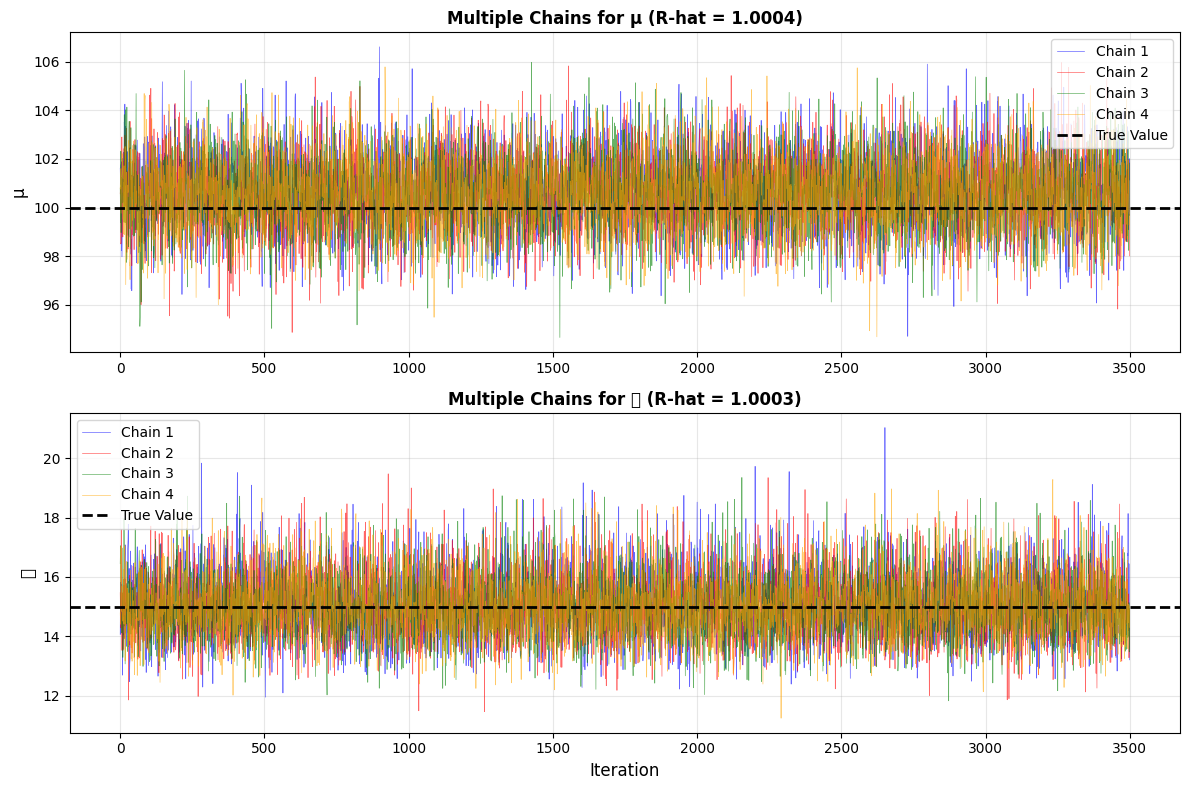

In [ ]:
# Extract samples
chains_mu = extract_chain_samples(results, 0)
chains_sigma = extract_chain_samples(results, 1)

# Compute R-hat with Gelman-Rubin from MCMC Diagnostics
markov_chains = results.MarkovChains
rhat = MCMCDiagnostics.GelmanRubin(markov_chains, int(0))
rhat_mu = float(rhat[0])
rhat_sigma = float(rhat[1])

print("Convergence Diagnostics (R-hat):")
print(f"μ:     {rhat_mu:.4f}  {'✓ Converged' if rhat_mu < 1.05 else 'X Not converged'}")
print(f"𝜎:     {rhat_sigma:.4f}  {'✓ Converged' if rhat_sigma < 1.05 else 'X Not converged'}")

# Plot chains
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

colors = ['blue', 'red', 'green', 'orange']
for i, chain in enumerate(chains_mu):
    axes[0].plot(chain, alpha=0.6, linewidth=0.5, label=f'Chain {i+1}', color=colors[i])
axes[0].axhline(true_mu, color='black', linestyle='--', linewidth=2, label='True Value')
axes[0].set_ylabel('μ', fontsize=12)
axes[0].set_title(f'Multiple Chains for μ (R-hat = {rhat_mu:.4f})', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

for i, chain in enumerate(chains_sigma):
    axes[1].plot(chain, alpha=0.6, linewidth=0.5, label=f'Chain {i+1}', color=colors[i])
axes[1].axhline(true_sigma, color='black', linestyle='--', linewidth=2, label='True Value')
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('σ', fontsize=12)
axes[1].set_title(f'Multiple Chains for σ (R-hat = {rhat_sigma:.4f})', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



## 3. Effective Sample Size (ESS) and Autocorrelation

ESS quantifies number of independent samples, accounting for autocorrelation. Higher is better.

**Guidelines:**
- **ESS > 400**: Excellent - precise estimates
- **ESS > 100**: Good - adequate for most purposes
- **ESS < 100**: Poor - increase iterations or improve mixing

**Autocorrelation impact:**
- High autocorrelation → Low ESS → Need more iterations
- Good mixing → High ESS → Efficient sampling

### ESS Formula

```math
\text{ESS} = \frac{N}{1 + 2\sum_{k=1}^{K} \rho_k}
```
where $N$ is the number of samples, $\rho_k$ is the autocorrelation at lag $k$, and the sum is truncated when $\rho_k$ becomes negligible.

### Mathematical Derivation

The ESS formula arises from analyzing the variance of the sample mean of a correlated sequence. For a stationary process $\lbrace\theta_1, \theta_2, \ldots, \theta_N\rbrace$ with marginal variance $\sigma^2$ and autocorrelation function $\rho_k = \text{Corr}(\theta_t, \theta_{t+k})$, the variance of the sample mean $\bar{\theta} = \frac{1}{N}\sum_{t=1}^{N}\theta_t$ is:

```math
\text{Var}(\bar{\theta}) = \frac{\sigma^2}{N}\left(1 + 2\sum_{k=1}^{N-1}\left(1 - \frac{k}{N}\right)\rho_k\right)
```

For large $N$, the $(1 - k/N)$ correction becomes negligible for the lags that matter, and the expression simplifies to:

```math
\text{Var}(\bar{\theta}) \approx \frac{\sigma^2}{N}\left(1 + 2\sum_{k=1}^{\infty}\rho_k\right)
```

If the samples were independent, we would have $\rho_k = 0$ for all $k \geq 1$, giving $\text{Var}(\bar{\theta}) = \sigma^2/N$. The effective sample size is defined as the number of *independent* samples that would give the same variance for the sample mean:

```math
\frac{\sigma^2}{\text{ESS}} = \frac{\sigma^2}{N}\left(1 + 2\sum_{k=1}^{\infty}\rho_k\right)
```

Solving for ESS:

```math
\text{ESS} = \frac{N}{1 + 2\sum_{k=1}^{\infty}\rho_k}
```

The quantity $\tau = 1 + 2\sum_{k=1}^{\infty}\rho_k$ is called the **integrated autocorrelation time**. It represents how many MCMC iterations correspond to one independent draw: $\text{ESS} = N/\tau$.

**Truncation strategy.** In practice, the infinite sum must be truncated. The ***Numerics*** implementation uses a simple truncation rule: the sum is cut off at the first lag $k$ where $\rho_k < 0$. This works because for a well-behaved MCMC chain, the autocorrelation function decays monotonically toward zero and oscillations below zero represent noise rather than genuine correlation.

Geyer (1992) [[3]](#3) proposed a more robust alternative called the **initial positive sequence estimator**, which sums consecutive *pairs* of autocorrelations $(\rho_{2k} + \rho_{2k+1})$ and stops when a pair sum becomes negative. This approach is theoretically guaranteed to produce a non-negative variance estimate. The ***Numerics*** implementation uses the simpler first-negative truncation, which is adequate for chains with good mixing behavior.

**Multi-chain ESS.** When $M$ chains of length $N$ are available, the implementation computes the autocorrelation sum $\rho_m$ for each chain $m$ separately, then averages across chains:

```math
\bar{\rho} = \frac{1}{M}\sum_{m=1}^{M}\rho_m \qquad \text{where} \quad \rho_m = \sum_{k=1}^{K_m}\hat{\rho}_k^{(m)}
```

Here $K_m$ is the truncation point for chain $m$ (the first lag at which the autocorrelation is negative). The total effective sample size is then:

```math
\text{ESS} = \frac{N \cdot M}{1 + 2\bar{\rho}}
```

This is capped at $N \cdot M$ (the total number of samples) since the effective sample size cannot exceed the actual number of draws.

### ESS Requirements

The minimum ESS needed depends on what posterior summary you are estimating:

| Inference Goal | Minimum ESS | Rationale |
|---------------|------------|-----------|
| Posterior mean | 100 | MCSE is approximately 10% of posterior SD |
| Posterior standard deviation | 200 | Variance estimation requires more samples than mean estimation |
| 95% credible interval | 400 | Quantile estimation demands greater precision in the tails |
| Tail probabilities (e.g., $P(\theta > c)$) | 1000+ | Extreme quantiles are estimated from sparse tail samples |

These thresholds are guidelines, not strict rules. For life-safety applications, err on the side of larger ESS.

### Autocorrelation Guidelines

| Lag-1 ACF | Interpretation | ESS Impact |
|-----------|---------------|------------|
| < 0.1 | Excellent mixing | ESS ≈ N |
| 0.1-0.3 | Good mixing | ESS ≈ 0.5N |
| 0.3-0.6 | Moderate | ESS ≈ 0.2N |
| > 0.6 | Poor mixing | ESS << 0.1N |

Effective Sample Size


,Metric,Value
0,Total samples,14000.00
1,ESS (μ),11052.62
2,ESS efficiency (μ),78.95
3,ESS (𝜎),12431.72
4,ESS efficiency (𝜎),88.80


C:\Users\q0rmcssn\AppData\Local\Temp\1\ipykernel_41428\2320077314.py:53: UserWarning: Glyph 120590 (\N{MATHEMATICAL ITALIC SMALL SIGMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\GIT\Numerics-Python-Examples\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 120590 (\N{MATHEMATICAL ITALIC SMALL SIGMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


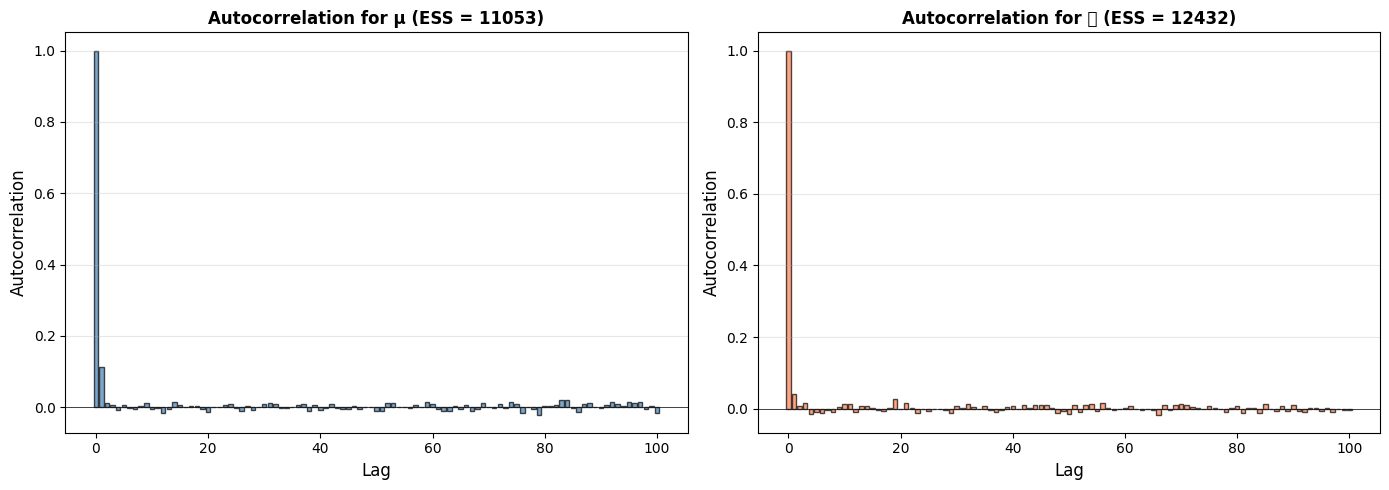

In [ ]:
# Combine all chains
combined_mu = np.asarray(np.concatenate(chains_mu), dtype=float)
combined_sigma = np.asarray(np.concatenate(chains_sigma), dtype=float)

# ESS with Numerics
ess_mu = float(MCMCDiagnostics.EffectiveSampleSize(convert_to_dotnet_array(combined_mu)))
ess_sigma = float(MCMCDiagnostics.EffectiveSampleSize(convert_to_dotnet_array(combined_sigma)))

ess_df = pd.DataFrame(
    {
        'Metric': ['Total samples', 'ESS (μ)', 'ESS efficiency (μ)', 'ESS (σ)', 'ESS efficiency (σ)'],
        'Value': [len(combined_mu), ess_mu, 100 * ess_mu / len(combined_mu), ess_sigma, 100 * ess_sigma / len(combined_sigma)],
    }
)
print("Effective Sample Size")
display(ess_df.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
max_lag = 100

# Autocorrelation from Numerics
acf_mu = Autocorrelation.Function(
    convert_to_dotnet_array(combined_mu),
    int(max_lag),
    Autocorrelation.Type.Correlation,
)
acf_sigma = Autocorrelation.Function(
    convert_to_dotnet_array(combined_sigma),
    int(max_lag),
    Autocorrelation.Type.Correlation,
)

lags_mu = np.array([int(acf_mu[i, 0]) for i in range(acf_mu.GetLength(0))], dtype=int)
autocorr_mu = np.array([float(acf_mu[i, 1]) for i in range(acf_mu.GetLength(0))], dtype=float)

lags_sigma = np.array([int(acf_sigma[i, 0]) for i in range(acf_sigma.GetLength(0))], dtype=int)
autocorr_sigma = np.array([float(acf_sigma[i, 1]) for i in range(acf_sigma.GetLength(0))], dtype=float)

axes[0].bar(lags_mu, autocorr_mu, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_xlabel('Lag', fontsize=12)
axes[0].set_ylabel('Autocorrelation', fontsize=12)
axes[0].set_title(f'Autocorrelation for μ (ESS = {ess_mu:.0f})', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(lags_sigma, autocorr_sigma, alpha=0.7, color='coral', edgecolor='black')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Lag', fontsize=12)
axes[1].set_ylabel('Autocorrelation', fontsize=12)
axes[1].set_title(f'Autocorrelation for σ (ESS = {ess_sigma:.0f})', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 4. Adaptive Sampling (ARWMH)
ARWMH automatically tunes the proposal distribution during warmup.

**Mathematical Foundation:** The key idea behind adaptive MCMC is to learn the proposal covariance from the chain's own history, eliminating the need for manual tuning. The optimal scaling theory of Roberts and Rosenthal (2001) shows that for Gaussian targets in $d$ dimensions, the optimal proposal covariance is:

```math
\Sigma_{\text{opt}} = \frac{2.38^2}{d} \, \Sigma_{\text{target}}
```

where $\Sigma_{\text{target}}$ is the covariance of the target distribution. Since the target covariance is unknown, ARWMH estimates it online from the chain history.

In the Numerics implementation (`ARWMH.cs`), the proposal at iteration $t$ uses a mixture:

```math
\theta^* \sim \begin{cases} \mathcal{N}\!\left(\theta, \, \frac{0.1^2}{d} \, I_d\right) & \text{with probability } \beta \\ \mathcal{N}\!\left(\theta, \, \frac{2.38^2}{d} \, \hat{\Sigma}_t\right) & \text{with probability } 1-\beta \end{cases}
```

where:

- $d$ is the number of parameters (`NumberOfParameters`)
- $\beta = 0.05$ by default (the `Beta` property)
- $\hat{\Sigma}_t$ is the empirical covariance matrix computed as a running covariance of accepted samples (and current states after warmup)
- $I_d$ is the $d$-dimensional identity matrix
- The scale factor $s = 2.38^2/d$ is the `Scale` property

The small identity component (used with probability $\beta$, and also for the first $100 \times d$ samples) ensures **ergodicity**: even if the adaptive covariance estimate is poor, the chain can still reach any region of the parameter space.

The acceptance criterion is identical to RWMH -- since both proposal components are symmetric multivariate normals centered at $\theta$, the Hastings ratio simplifies to the posterior ratio.

**When to use ARWMH:**
- Medium-dimensional problems (2-20 parameters)
- When you don't want to manually tune proposals
- Correlated parameters
- Default choice for most applications

**Advantages:**
- No manual tuning required
- Adapts to parameter correlations
- Generally more efficient than fixed RWMH

Adaptive RWMH Results


,Metric,Value,True
0,μ,100.606,100
1,𝜎 estimate,15.026,15
2,ESS (μ),13773.302,---
3,ESS (𝜎),11596.742,---


Acceptance rates by chain


,Chain,Acceptance Rate
0,0,0.377
1,1,0.377
2,2,0.371
3,3,0.371


C:\Users\q0rmcssn\AppData\Local\Temp\1\ipykernel_41428\338597997.py:30: UserWarning: Glyph 120590 (\N{MATHEMATICAL ITALIC SMALL SIGMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\GIT\Numerics-Python-Examples\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 120590 (\N{MATHEMATICAL ITALIC SMALL SIGMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


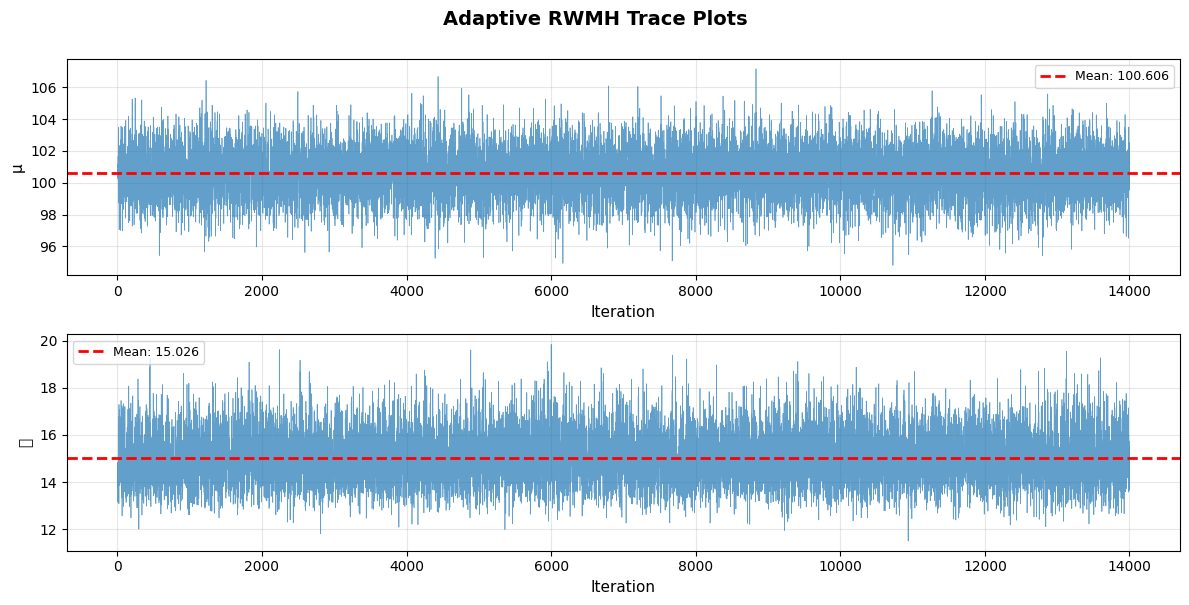

C:\Users\q0rmcssn\AppData\Local\Temp\1\ipykernel_41428\338597997.py:55: UserWarning: Glyph 120590 (\N{MATHEMATICAL ITALIC SMALL SIGMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


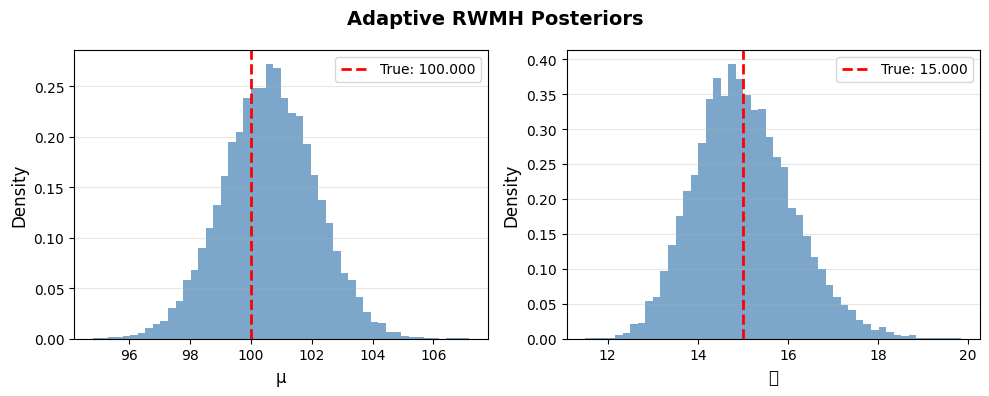

In [ ]:
# Create ARWMH sampler
arwmh = ARWMH(priors, log_lik_func)
arwmh.BurnIn = 2000
arwmh.SampleSize = 5000
arwmh.Sample()
arwmh_results = MCMCResults(arwmh)

mu_samples = extract_chain_samples(arwmh_results, 0)
sigma_samples = extract_chain_samples(arwmh_results, 1)
combined_mu = np.asarray(np.concatenate(mu_samples), dtype=float)
combined_sigma = np.asarray(np.concatenate(sigma_samples), dtype=float)

ess_mu = float(MCMCDiagnostics.EffectiveSampleSize(convert_to_dotnet_array(combined_mu)))
ess_sigma = float(MCMCDiagnostics.EffectiveSampleSize(convert_to_dotnet_array(combined_sigma)))

arwmh_df = pd.DataFrame(
    {
        'Metric': ['μ', 'σ estimate', 'ESS (μ)', 'ESS (σ)'],
        'Value': [np.mean(combined_mu), np.mean(combined_sigma), ess_mu, ess_sigma],
        'True': [true_mu, true_sigma, "---", "---"],
    }
)
print("Adaptive RWMH Results")
display(arwmh_df.round(3))

acc_df = pd.DataFrame({'Chain': list(range(len(arwmh.AcceptanceRates))), 'Acceptance Rate': list(arwmh.AcceptanceRates)})
print("Acceptance rates by chain")
display(acc_df.round(3))

plot_trace([combined_mu, combined_sigma], ['μ', '𝜎'], title="Adaptive RWMH Trace Plots")
plot_posterior([combined_mu, combined_sigma], ['μ', '𝜎'], [true_mu, true_sigma], title="Adaptive RWMH Posteriors")


## 5. Handling Multimodal Posteriors

Some posteriors have multiple peaks. DEMCz and DEMCzs are better at exploring these.

Differential Evolution MCMC (DEMCz) is a population-based sampler using differential evolution.

**Mathematical Foundation:** DEMCz combines differential evolution (DE) with MCMC by using a population of chains and a history of past states to generate proposals. The mutation formula from the source code (`DEMCz.cs`) is:

```math
\theta^*_i = \theta_i + \gamma \, (z_{R_1} - z_{R_2}) + e
```

where:

- $\gamma = 2.38 / \sqrt{2d}$ is the default jump rate (`Jump` property), with $d$ the number of parameters
- $z_{R_1}$ and $z_{R_2}$ are two randomly selected states from the **population matrix** (a memory of past states from all chains)
- $e \sim \mathcal{N}(0, b^2)$ is a small noise perturbation with default $b = 10^{-3}$ (`Noise` property)
- $R_1$ and $R_2$ are drawn uniformly without replacement from $\lbrace 1, 2, \ldots, M\rbrace$, where $M$ is the current size of the population matrix

The proposal is accepted using the standard Metropolis ratio in log space:

```math
\log \alpha = \log \pi(\theta^*) - \log \pi(\theta)
```

To enable **mode-jumping** in multimodal posteriors, the jump rate $\gamma$ is set to $1.0$ with probability equal to `JumpThreshold` (default 0.1). When $\gamma = 1$, the proposal jumps the full difference between two past states, which can bridge gaps between separated modes.

The key insight of DEMCz is that the population matrix $Z$ serves as a memory of past states from **all** chains, providing a rich set of difference vectors for generating proposals. This eliminates the need for a manually specified proposal covariance matrix -- the population automatically learns the scale and orientation of the posterior.

**When to use DEMCz:**
- High-dimensional problems (20+ parameters)
- Multimodal posteriors
- Complex posterior geometry
- When ARWMH struggles with convergence

**Advantages:**
- Excellent for high dimensions
- Handles multimodal distributions
- Robust to initialization
- Self-tuning proposals from population

DEMCz with Snooker Update (DEMCzs)is an enhanced version with improved mixing.

Fitting mixture model with DEMCz...

Mixture Model Estimates:


,Parameter,Mean,Weight
0,μ1,98.48,0.5
1,𝜎1,10.93,0.5
2,μ2,100.51,0.5
3,𝜎2,10.87,0.5


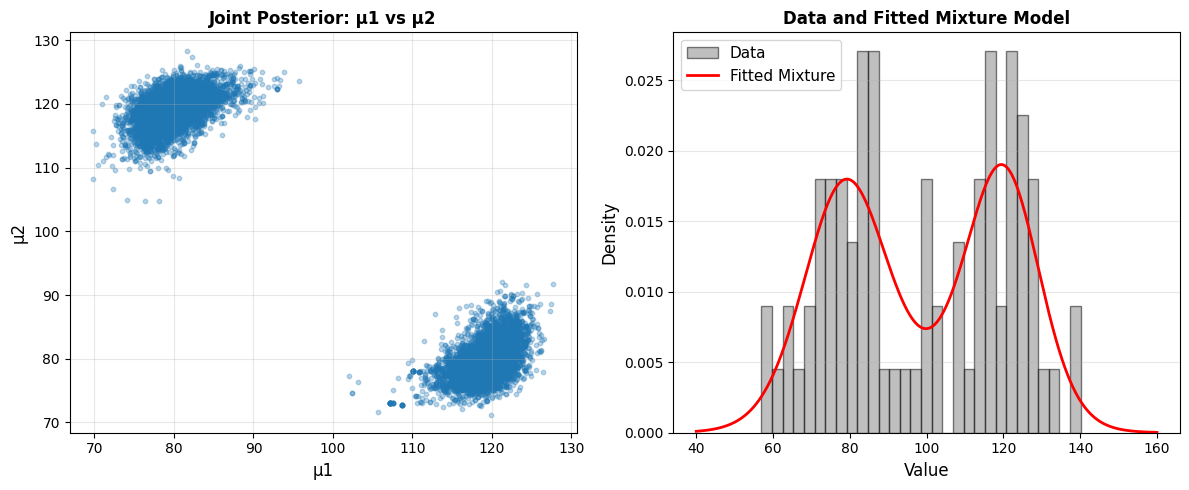

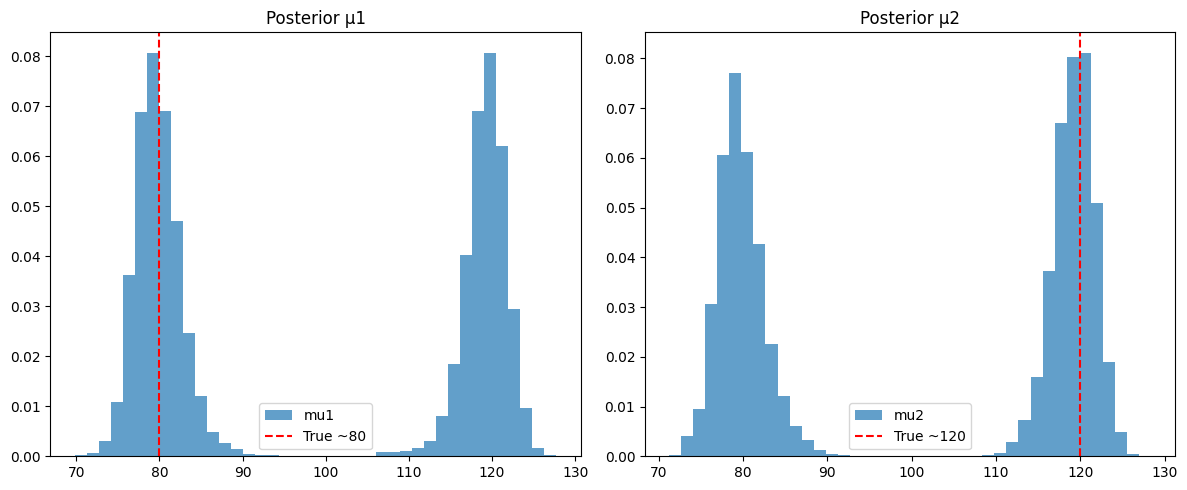

In [ ]:
# Create bimodal mixture data
np.random.seed(789)
mode1 = Normal(80, 10).GenerateRandomValues(40, 789)
mode2 = Normal(120, 10).GenerateRandomValues(40, 789)
bimodal_data = np.concatenate([list(mode1), list(mode2)])
bimodal_net = convert_to_dotnet_array(bimodal_data)

# Priors for mixture model
priors_mixture = List[IUnivariateDistribution]()
priors_mixture.Add(Uniform(50, 150))   # mu1
priors_mixture.Add(Uniform(5, 20))     # sigma1
priors_mixture.Add(Uniform(50, 150))   # mu2
priors_mixture.Add(Uniform(5, 20))     # sigma2
priors_mixture.Add(Uniform(0.01, 0.99))  # weight

# Mixture model log-likelihood
def log_lik_mixture(params):
    mu1, sigma1, mu2, sigma2, weight = params[0], params[1], params[2], params[3], params[4]
    
    dist1 = Normal(mu1, sigma1)
    dist2 = Normal(mu2, sigma2)
    
    total_ll = 0
    for x in bimodal_data:
        prob = weight * np.exp(dist1.LogPDF(x)) + (1 - weight) * np.exp(dist2.LogPDF(x))
        if prob > 0:
            total_ll += np.log(prob)
        else:
            total_ll += -1e10
    
    return total_ll

log_lik_mixture_func = LogLikelihood(log_lik_mixture)

# Use DEMCz for multimodal posterior
print("Fitting mixture model with DEMCz...")
demcz = DEMCz(priors_mixture, log_lik_mixture_func)
demcz.BurnIn = 3000
demcz.SampleSize = 10000

demcz.Sample()
results = MCMCResults(demcz)

mu1_chains = extract_chain_samples(results, 0)
sigma1_chains = extract_chain_samples(results, 1)
mu2_chains = extract_chain_samples(results, 2)
sigma2_chains = extract_chain_samples(results, 3)
weight_chains = extract_chain_samples(results, 4)

mu1_samples = np.concatenate(mu1_chains)
sigma1_samples = np.concatenate(sigma1_chains)
mu2_samples = np.concatenate(mu2_chains)
sigma2_samples = np.concatenate(sigma2_chains)
weight_samples = np.concatenate(weight_chains)

print("\nMixture Model Estimates:")
summary_table = pd.DataFrame({
    'Parameter': ['μ1', 'σ1', 'μ2', 'σ2'],
    'Mean': [np.mean(mu1_samples), np.mean(sigma1_samples), np.mean(mu2_samples), np.mean(sigma2_samples)],
    'Weight': np.mean(weight_samples)
})
display(summary_table.round(2))

# Joint posterior plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(mu1_samples, mu2_samples, alpha=0.3, s=10)
plt.xlabel('μ1', fontsize=12)
plt.ylabel('μ2', fontsize=12)
plt.title('Joint Posterior: μ1 vs μ2', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(bimodal_data, bins=30, density=True, alpha=0.5, color='gray', 
         edgecolor='black', label='Data')
x_range = np.linspace(40, 160, 500)
mean_weight = np.mean(weight_samples)


# Use a subset of posterior samples to approximate posterior predictive
idx = np.random.choice(len(mu1_samples), size=min(1000, len(mu1_samples)), replace=False)

pdf_mixture = []
for x in x_range:
    vals = []
    for j in idx:
        d1 = Normal(mu1_samples[j], sigma1_samples[j])
        d2 = Normal(mu2_samples[j], sigma2_samples[j])
        vals.append(weight_samples[j] * d1.PDF(x) + (1 - weight_samples[j]) * d2.PDF(x))
    pdf_mixture.append(np.mean(vals))

plt.plot(x_range, pdf_mixture, 'r-', linewidth=2, label='Fitted Mixture')
plt.xlabel('Value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Data and Fitted Mixture Model', fontsize=12, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Marginal posterior plots
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(mu1_samples, bins=40, alpha=0.7, density=True, label='mu1')
plt.axvline(80, color='red', linestyle='--', label='True ~80')
plt.legend(); plt.title('Posterior μ1')

plt.subplot(1,2,2)
plt.hist(mu2_samples, bins=40, alpha=0.7, density=True, label='mu2')
plt.axvline(120, color='red', linestyle='--', label='True ~120')
plt.legend(); plt.title('Posterior μ2')

plt.tight_layout()
plt.show()


## 6. Comparing MCMC Samplers

Different samplers have different strengths. We will compare all of our adaptive samplers:

- **ARWMH**: Adaptive Random Walk MH (auto-tuning)
- **DEMCz**: Differential Evolution MCMC (population-based)
- **DEMCzs**: DEMCz with snooker update (better for complex posteriors)
- **HMC**: Hamiltonian Monte Carlo (uses gradients)
- **NUTS** No-U Turn Sanpler (adaptive HMC)

Before we start, let's go through the our last two samplers.

Hamiltonian Monte Carlo (HMC) uses gradient information for efficient sampling.

**Mathematical Foundation:** HMC augments the parameter space with auxiliary momentum variables $\phi$ and simulates Hamiltonian dynamics to generate distant, high-quality proposals. The Hamiltonian is defined as:

```math
H(\theta, \phi) = U(\theta) + K(\phi) = -\log \pi(\theta) + \frac{1}{2} \phi^T M^{-1} \phi
```

where $U(\theta) = -\log \pi(\theta)$ is the **potential energy** (negative log-posterior) and $K(\phi)$ is the **kinetic energy**. The mass matrix $M$ is diagonal in the Numerics implementation (the `Mass` vector property).

Hamilton's equations of motion govern the dynamics:

```math
\frac{d\theta}{dt} = \frac{\partial H}{\partial \phi} = M^{-1}\phi, \qquad \frac{d\phi}{dt} = -\frac{\partial H}{\partial \theta} = \nabla \log \pi(\theta)
```

These continuous dynamics are approximated using the **leapfrog integrator**, as implemented in `HMC.cs`:

1. Half-step momentum: $\phi \leftarrow \phi + \frac{\varepsilon}{2} \nabla \log \pi(\theta)$
2. Full-step position: $\theta \leftarrow \theta + \varepsilon \, M^{-1} \phi$
3. Half-step momentum: $\phi \leftarrow \phi + \frac{\varepsilon}{2} \nabla \log \pi(\theta)$

Steps 2-3 are repeated for $L$ leapfrog steps. After the trajectory, a Metropolis correction accounts for numerical integration error:

```math
\alpha = \min\left(1, \exp\!\left(-H(\theta^*, \phi^*) + H(\theta, \phi)\right)\right)
```

In log space, the source code computes this as:

```math
\log \alpha = \left[\log \pi(\theta^*) - \frac{1}{2}\phi^{*T} M^{-1} \phi^*\right] - \left[\log \pi(\theta) - \frac{1}{2}\phi^T M^{-1} \phi\right]
```

**Implementation details from `HMC.cs`:**

- The step size $\varepsilon$ is **jittered**: each iteration draws $\varepsilon \sim \text{Uniform}(0, \, 2\varepsilon_0)$ where $\varepsilon_0$ is the `StepSize` property. This avoids resonant trajectories.
- The number of leapfrog steps $L$ is **jittered**: each iteration draws $L \sim \text{UniformDiscrete}(1, \, 2L_0)$ where $L_0$ is the `Steps` property.
- The mass vector $M$ is diagonal (default: identity). Users can set it via the `mass` constructor parameter.
- If no gradient function is provided, numerical finite differences are used via `NumericalDerivative.Gradient`, with probes clamped to prior bounds.

**When to use HMC:**
- Smooth, differentiable posteriors
- When gradient information is available
- Need for low autocorrelation
- Medium to high dimensions with smooth geometry

**Advantages:**
- Very efficient (low autocorrelation)
- Explores parameter space quickly
- Excellent for smooth posteriors

**Disadvantages:**
- Requires gradient computation
- Less robust to discontinuities
- More complex to tune

No-U-Turn Sampler (NUTS) automatically tunes the trajectory length that HMC requires as a manual setting, making it the recommended gradient-based sampler for most problems.

**Mathematical Foundation:** NUTS eliminates HMC's most sensitive tuning parameter -- the number of leapfrog steps $L$ -- by automatically determining when to stop the trajectory. It builds a balanced binary tree of leapfrog states using the following procedure:

1. Sample momentum $\phi \sim \mathcal{N}(0, M)$
2. Recursively double the trajectory in a randomly chosen direction (forward or backward)
3. Stop when a **U-turn** is detected or the maximum tree depth is reached

The **U-turn criterion** (from `NUTS.cs`) checks whether the trajectory endpoints are moving apart or starting to return:

```math
(\theta^+ - \theta^-) \cdot \phi^- < 0 \quad \text{or} \quad (\theta^+ - \theta^-) \cdot \phi^+ < 0
```

where $\theta^+$ and $\theta^-$ are the forward and backward endpoints of the trajectory, and $\phi^+$ and $\phi^-$ are their corresponding momenta. When either dot product is negative, the trajectory has started to curve back on itself.

**Candidate selection** uses multinomial sampling weighted by $\exp(-H)$:

```math
P(\text{select } \theta_j) = \frac{\exp(-H(\theta_j, \phi_j))}{\sum_k \exp(-H(\theta_k, \phi_k))}
```

This is implemented via log-sum-exp arithmetic for numerical stability.

**Step size adaptation** uses the dual averaging scheme from Hoffman and Gelman (2014), Algorithm 5. The running statistic $\bar{H}_m$ is updated at each adaptation step $m$:

```math
\bar{H}_m = \left(1 - \frac{1}{m + t_0}\right)\bar{H}_{m-1} + \frac{1}{m + t_0}(\delta - \alpha_m)
```

```math
\log \varepsilon_m = \mu - \frac{\sqrt{m}}{\gamma}\bar{H}_m
```

where:

- $\delta = 0.80$ is the target acceptance rate (`DELTA_TARGET`)
- $\gamma = 0.05$ is the adaptation regularization (`GAMMA`)
- $t_0 = 10$ prevents early instability (`T0`)
- $\mu = \log(10 \cdot \varepsilon_0)$ is the bias point, with $\varepsilon_0$ the initial step size
- $\alpha_m$ is the average Metropolis acceptance probability from the current tree

The smoothed step size uses an exponential moving average with decay exponent $\kappa = 0.75$:

```math
\log \bar{\varepsilon}_m = m^{-\kappa} \log \varepsilon_m + (1 - m^{-\kappa}) \log \bar{\varepsilon}_{m-1}
```

After warmup, the step size is fixed to $\exp(\log \bar{\varepsilon})$.

**Implementation details from `NUTS.cs`:**

- `MaxTreeDepth` defaults to 10, capping trajectories at $2^{10} = 1024$ leapfrog steps
- Divergence threshold: if $H - H_0 > 1000$, the trajectory is considered divergent and tree-building stops
- NUTS always accepts a candidate from the tree (acceptance is built into the multinomial weighting), so `AcceptCount` increments every iteration
- Step size adaptation occurs only during the warmup phase, with step sizes clamped to $[10^{-10}, \, 10^{5}]$

**When to use NUTS:**
- Smooth, differentiable posteriors (same as HMC)
- When you don't want to tune the number of leapfrog steps
- Default gradient-based sampler for most applications
- Medium to high dimensions

**Advantages over HMC:**
- No manual tuning of trajectory length
- Adapts step size automatically via dual averaging
- Eliminates wasteful U-turns in the trajectory
- Generally more efficient per computation

**Key settings:**
- `stepSize`: Initial leapfrog step size (adapted during warmup)
- `maxTreeDepth`: Maximum binary tree depth (default 10, caps trajectory at 2^10 = 1024 steps)
- `gradientFunction`: Optional analytical gradient, provided as a constructor parameter only (not a settable property). If not provided, numerical finite differences are used.


### Weibull Example: Comparing All Adaptive Samplers

Fit a Weibull distribution to reliability data using different samplers. While we shouldn't normally compare adaptive and nonadaptive samplers, here we want to focus mainly on runtimes.

Again, we wil draw random samples from the posterior and graph their chains (CODEX: fix here)

In [8]:
# Generate Weibull data (failure times)
true_lambda = 100
true_kappa = 2.5
failure_times = list(Weibull(true_lambda, true_kappa).GenerateRandomValues(50, 12345))

priors_weibull = List[IUnivariateDistribution]()
priors_weibull.Add(Uniform(50, 200))
priors_weibull.Add(Uniform(1, 5))

def log_lik_weibull(params):
    dist = Weibull(params[0], params[1])
    return sum(dist.LogPDF(x) for x in failure_times)

log_lik_weibull_func = LogLikelihood(log_lik_weibull)

samplers_to_test = {
    'ARWMH': lambda: ARWMH(priors_weibull, log_lik_weibull_func),
    'DEMCz': lambda: DEMCz(priors_weibull, log_lik_weibull_func),
    'DEMCzs': lambda: DEMCzs(priors_weibull, log_lik_weibull_func),
    # 'HMC' : lambda: HMC(priors_weibull, log_lik_weibull_func)  takes 20+ minutes to run on its own
    # ADD NUTS ONCE PUSHED
}

out_results = {}
summary_rows = []
print("Comparing MCMC samplers...")

for name, create_sampler in samplers_to_test.items():
    print(f"Running {name}...")
    sampler = create_sampler()
    sampler.BurnIn = 1000
    sampler.SampleSize = 5000

    start = time.time()
    sampler.Sample()
    elapsed = time.time() - start

    results = MCMCResults(sampler)
    chains_lambda = extract_chain_samples(results, 0)
    chains_kappa = extract_chain_samples(results, 1)

    combined_lambda = np.asarray(np.concatenate(chains_lambda), dtype=float)
    combined_kappa = np.asarray(np.concatenate(chains_kappa), dtype=float)

    est_lambda = np.mean(combined_lambda)
    est_kappa = np.mean(combined_kappa)
    ess_lambda = float(MCMCDiagnostics.EffectiveSampleSize(convert_to_dotnet_array(combined_lambda))) if combined_lambda.size > 0 else 0.0
    ess_kappa = float(MCMCDiagnostics.EffectiveSampleSize(convert_to_dotnet_array(combined_kappa))) if combined_kappa.size > 0 else 0.0

    out_results[name] = {'lambda': combined_lambda, 'kappa': combined_kappa, 'time': elapsed, 'ess_lambda': ess_lambda, 'ess_kappa': ess_kappa}

    summary_rows.append({'Sampler': name, 'Runtime (s)': elapsed, 'λ Estimate': est_lambda, 'κ Estimate': est_kappa, 'λ Error': est_lambda - true_lambda, 'κ Error': est_kappa - true_kappa, 'ESS (λ)': ess_lambda, 'ESS (κ)': ess_kappa})

summary_df = pd.DataFrame(summary_rows).sort_values('Runtime (s)')
print("Sampler comparison summary")
display(summary_df.round(3))

Comparing MCMC samplers...
Running ARWMH...
Running DEMCz...
Running DEMCzs...
Sampler comparison summary


,Sampler,Runtime (s),λ Estimate,κ Estimate,λ Error,κ Error,ESS (λ),ESS (κ)
1,DEMCz,135.619,108.899,2.689,8.899,0.189,12179.087,12712.395
2,DEMCzs,136.447,108.914,2.695,8.914,0.195,12984.905,13318.703
0,ARWMH,145.016,108.938,2.691,8.938,0.191,13357.007,13772.278


### Normal Example: Comparing NUTS vs DEMCzs vs PyMC 
This comparison uses the same Normal likelihood and priors. It aligns the number of draws so the summary statistics are comparable.

**Performance Preview:** In the benchmark below, Numerics DEMCzs often runs faster than PyMC. Your results may vary by machine, sampler settings, and version.

**Note:** Numerics applies thinning by default, so its MarkovChains are already thinned. When comparing to PyMC, match PyMC draws to the Numerics chain length or set Numerics ThinningInterval to 1.

In [ ]:
# from Numerics.Sampling.MCMC import NUTS
# nuts_results = None
# try:
#     nuts = NUTS(priors, log_lik_func)
#     nuts.ThinningInterval = 1
#     nuts.WarmupIterations = 1000
#     nuts.Iterations = 2000
#     nuts.NumberOfChains = 1

#     t0 = time.perf_counter()
#     nuts.Sample()
#     nuts_runtime_s = time.perf_counter() - t0

#     nuts_results = MCMCResults(nuts)
#     print("Numerics NUTS complete")
# except Exception as e:
#     nuts_runtime_s = np.nan
#     print("Numerics NUTS not available in this build or failed to initialize:")
#     print(e)

# demczs = DEMCzs(priors, log_lik_func)
# demczs.ThinningInterval = 1
# demczs.WarmupIterations = 1000
# demczs.Iterations = 2000
# demczs.NumberOfChains = 3  # DEMCzs requires at least 3 chains

# t0 = time.perf_counter()
# demczs.Sample()
# demczs_runtime_s = time.perf_counter() - t0

# demczs_results = MCMCResults(demczs)

# y_obs = np.asarray(list(data), dtype=float)

# # Match draws to Numerics kept samples per chain
# target_draws = len(demczs_results.MarkovChains[0])
# if nuts_results is not None:
#     target_draws = len(nuts_results.MarkovChains[0])

# # Explicitly set values to avoid version-dependent defaults
# target_tune = 1000
# target_accept = 0.8

# t0 = time.perf_counter()
# with pm.Model() as model:
#     mu = pm.Uniform("mu", lower=50, upper=150)
#     sigma = pm.Uniform("sigma", lower=5, upper=30)
#     pm.Normal("y", mu=mu, sigma=sigma, observed=y_obs)

#     trace = pm.sample(
#         draws=target_draws,
#         tune=target_tune,
#         chains=1,
#         cores=1,
#         target_accept=target_accept,
#         random_seed=12345,
#         progressbar=False,
#         )

# pymc_runtime_s = time.perf_counter() - t0

# mu_pymc = trace.posterior["mu"].values.ravel()
# sigma_pymc = trace.posterior["sigma"].values.ravel()

# # Summary table
# rows = []

# demczs_chain0 = demczs_results.MarkovChains[0]
# rows.append(
#     {
#         "Sampler": "DEMCzs (Numerics)",
#         "Mean μ": float(np.mean([v.Values[0] for v in demczs_chain0])),
#         "Mean 𝜎": float(np.mean([v.Values[1] for v in demczs_chain0])),
#         "Runtime (s)": float(demczs_runtime_s),
#     }
# )

# if nuts_results is not None:
#     nuts_chain0 = nuts_results.MarkovChains[0]
#     rows.append(
#         {
#             "Sampler": "NUTS (Numerics)",
#             "Mean μ": float(np.mean([v.Values[0] for v in nuts_chain0])),
#             "Mean 𝜎": float(np.mean([v.Values[1] for v in nuts_chain0])),
#             "Runtime (s)": float(nuts_runtime_s),
#         }
#     )

# if mu_pymc.size > 0:
#     rows.append(
#         {
#             "Sampler": "NUTS (PyMC)",
#             "Mean μ": float(np.mean(mu_pymc)),
#             "Mean 𝜎": float(np.mean(sigma_pymc)),
#             "Runtime (s)": float(pymc_runtime_s),
#         }
#     )

# compare_df = pd.DataFrame(rows)
# display(compare_df)

ImportError: cannot import name 'NUTS' from 'Numerics.Sampling.MCMC' (unknown location)

### More PyMC Comparison Tests
Above we tested Numerics against PyMC for a Normal distribution. Below are more comparison tests for the various distributions in Numerics. Since MCMC methods rely on random number generation, Numerics results will not be exactly the same as those produced by PyMC. Therefore, these comparisons aim to verify whether the results are within 5% of each other.

**Note:** The code block below takes a long time to run; a lot longer than the cells we've been running above.

In [5]:
try:
    import pymc as pm

    flood_data = Array[Double]([
    6290, 2700, 13100, 16900, 14600, 9600, 7740, 8490, 8130, 12000, 
    17200, 15000, 12400, 6960, 6500, 5840, 10400, 18800, 21400, 22600, 
    14200, 11000, 12800, 15700, 4740, 6950, 11800, 12100, 20600, 14600, 
    14600, 8900, 10600, 14200, 14100, 14100, 12500, 7530, 13400, 17600, 
    13400, 19200, 16900, 15500, 14500, 21900, 10400, 7460])

    # Shared PyMC data
    pymc_data = np.array(list(flood_data))

    # Logistic distribution Comparison
    print("Logistic Distribution [PyMC Comparison]")

    log = Logistic()
    constraints_log = log.GetParameterConstraints(flood_data)
    xi_prior = Uniform(constraints_log.Item2[0], constraints_log.Item3[0])
    alpha_prior = Uniform(constraints_log.Item2[1], constraints_log.Item3[1])
    priors_logistic = List[IUnivariateDistribution]()
    priors_logistic.Add(xi_prior)
    priors_logistic.Add(alpha_prior)

    def log_likelihood_logistic(params):
        dist = Logistic(params[0], params[1])
        return dist.LogLikelihood(flood_data)

    log_lik_func = LogLikelihood(log_likelihood_logistic)

    log_numerics_start = time.perf_counter()
    sampler_logistic = DEMCzs(priors_logistic, log_lik_func)
    sampler_logistic.Sample()
    results_logistic = MCMCResults(sampler_logistic)
    log_numerics_time = time.perf_counter() - log_numerics_start

    log_pymc_start = time.perf_counter()

    with pm.Model() as model:
        xi = pm.Uniform('xi', lower=constraints_log.Item2[0], upper=constraints_log.Item3[0])
        alpha = pm.Uniform('alpha', lower=constraints_log.Item2[1], upper=constraints_log.Item3[1])
        y = pm.Logistic('y', mu=xi, s=alpha, observed=pymc_data)
        # Added: Numerics returns thinned samples by default, so match PyMC draws to Numerics chain length
        target_draws = len(results_logistic.MarkovChains[0])
        target_tune = sampler_logistic.WarmupIterations
        trace = pm.sample(draws=target_draws, tune=target_tune, chains=1, progressbar=False, random_seed=12345)

    xiSamples = trace.posterior['xi'].values.flatten()
    alphaSamples = trace.posterior['alpha'].values.flatten()

    log_pymc_time = time.perf_counter() - log_pymc_start

    numericsResults = [
        results_logistic.ParameterResults[0].SummaryStatistics.Mean,
        results_logistic.ParameterResults[0].SummaryStatistics.StandardDeviation,
        results_logistic.ParameterResults[0].SummaryStatistics.LowerCI,
        results_logistic.ParameterResults[0].SummaryStatistics.Median,
        results_logistic.ParameterResults[0].SummaryStatistics.UpperCI,
        results_logistic.ParameterResults[1].SummaryStatistics.Mean,
        results_logistic.ParameterResults[1].SummaryStatistics.StandardDeviation,
        results_logistic.ParameterResults[1].SummaryStatistics.LowerCI,
        results_logistic.ParameterResults[1].SummaryStatistics.Median,
        results_logistic.ParameterResults[1].SummaryStatistics.UpperCI
    ]

    comparisonResults = [
        np.mean(xiSamples), np.std(xiSamples), np.percentile(xiSamples, 5), np.median(xiSamples), np.percentile(xiSamples, 95),
        np.mean(alphaSamples), np.std(alphaSamples), np.percentile(alphaSamples, 5), np.median(alphaSamples), np.percentile(alphaSamples, 95)
    ]

    parameterNames = ['Xi Mean', 'Xi StdDev', 'Xi Lower CI', 'Xi Median', 'Xi Upper CI',
                      'Alpha Mean', 'Alpha StdDev', 'Alpha Lower CI', 'Alpha Median', 'Alpha Upper CI']

    comparison_df = create_comparison_table(numericsResults, 'PyMC', comparisonResults, parameterNames, log_numerics_time, log_pymc_time)
    display(comparison_df)
    print(f"Speedup: {log_pymc_time/log_numerics_time:.2f}x faster with Numerics\n")

    # Gumbel distribution Comparison
    print("Gumbel Distribution [PyMC Comparison]")

    gumbel = Gumbel()
    constraints_gumbel = gumbel.GetParameterConstraints(flood_data)
    xi_prior = Uniform(constraints_gumbel.Item2[0], constraints_gumbel.Item3[0])
    alpha_prior = Uniform(constraints_gumbel.Item2[1], constraints_gumbel.Item3[1])
    priors_gumbel = List[IUnivariateDistribution]()
    priors_gumbel.Add(xi_prior)
    priors_gumbel.Add(alpha_prior)

    def log_likelihood_gumbel(params):
        dist = Gumbel(params[0], params[1])
        return dist.LogLikelihood(flood_data)

    gumbel_lik_func = LogLikelihood(log_likelihood_gumbel)

    gumbel_numerics_start = time.perf_counter()
    sampler_gumbel = DEMCzs(priors_gumbel, gumbel_lik_func)
    sampler_gumbel.Sample()
    results_gumbel = MCMCResults(sampler_gumbel)
    gumbel_numerics_time = time.perf_counter() - gumbel_numerics_start

    gumbel_pymc_start = time.perf_counter()

    with pm.Model() as model:
        xi = pm.Uniform('xi', lower=constraints_gumbel.Item2[0], upper=constraints_gumbel.Item3[0])
        alpha = pm.Uniform('alpha', lower=constraints_gumbel.Item2[1], upper=constraints_gumbel.Item3[1])
        y = pm.Gumbel('y', mu=xi, beta=alpha, observed=pymc_data)
        # Added: Numerics returns thinned samples by default, so match PyMC draws to Numerics chain length
        target_draws = len(results_gumbel.MarkovChains[0])
        target_tune = sampler_gumbel.WarmupIterations
        trace = pm.sample(draws=target_draws, tune=target_tune, chains=1, progressbar=False, random_seed=12345)

    xiSamples = trace.posterior['xi'].values.flatten()
    alphaSamples = trace.posterior['alpha'].values.flatten()

    gumbel_pymc_time = time.perf_counter() - gumbel_pymc_start

    numericsResults = [
        results_gumbel.ParameterResults[0].SummaryStatistics.Mean,
        results_gumbel.ParameterResults[0].SummaryStatistics.StandardDeviation,
        results_gumbel.ParameterResults[0].SummaryStatistics.LowerCI,
        results_gumbel.ParameterResults[0].SummaryStatistics.Median,
        results_gumbel.ParameterResults[0].SummaryStatistics.UpperCI,
        results_gumbel.ParameterResults[1].SummaryStatistics.Mean,
        results_gumbel.ParameterResults[1].SummaryStatistics.StandardDeviation,
        results_gumbel.ParameterResults[1].SummaryStatistics.LowerCI,
        results_gumbel.ParameterResults[1].SummaryStatistics.Median,
        results_gumbel.ParameterResults[1].SummaryStatistics.UpperCI
    ]

    comparisonResults = [
        np.mean(xiSamples), np.std(xiSamples), np.percentile(xiSamples, 5), np.median(xiSamples), np.percentile(xiSamples, 95),
        np.mean(alphaSamples), np.std(alphaSamples), np.percentile(alphaSamples, 5), np.median(alphaSamples), np.percentile(alphaSamples, 95)
    ]

    parameterNames = ['Xi Mean', 'Xi StdDev', 'Xi Lower CI', 'Xi Median', 'Xi Upper CI',
                      'Alpha Mean', 'Alpha StdDev', 'Alpha Lower CI', 'Alpha Median', 'Alpha Upper CI']

    comparison_df = create_comparison_table(numericsResults, 'PyMC', comparisonResults, parameterNames, gumbel_numerics_time, gumbel_pymc_time)
    display(comparison_df)
    print(f"Speedup: {gumbel_pymc_time/gumbel_numerics_time:.2f}x faster with Numerics\n")

    # Weibull distribution Comparison
    print("Weibull Distribution [PyMC Comparison]")

    weibull = Weibull()
    constraints_weibull = weibull.GetParameterConstraints(flood_data)
    lambda_prior = Uniform(constraints_weibull.Item2[0], constraints_weibull.Item3[0])
    kappa_prior = Uniform(constraints_weibull.Item2[1], constraints_weibull.Item3[1])
    priors_weibull = List[IUnivariateDistribution]()
    priors_weibull.Add(lambda_prior)
    priors_weibull.Add(kappa_prior)

    def log_likelihood_weibull(params):
        dist = Weibull(params[0], params[1])
        return dist.LogLikelihood(flood_data)

    weibull_lik_func = LogLikelihood(log_likelihood_weibull)

    weibull_numerics_start = time.perf_counter()
    sampler_weibull = DEMCzs(priors_weibull, weibull_lik_func)
    sampler_weibull.Sample()
    results_weibull = MCMCResults(sampler_weibull)
    weibull_numerics_time = time.perf_counter() - weibull_numerics_start

    weibull_pymc_start = time.perf_counter()

    with pm.Model() as model:
        kappa = pm.Uniform('kappa', lower=constraints_weibull.Item2[1], upper=constraints_weibull.Item3[1])
        lambda_ = pm.Uniform('lambda', lower=constraints_weibull.Item2[0], upper=constraints_weibull.Item3[0])
        y = pm.Weibull('y', alpha=kappa, beta=lambda_, observed=pymc_data)
        # Added: Numerics returns thinned samples by default, so match PyMC draws to Numerics chain length
        target_draws = len(results_weibull.MarkovChains[0])
        target_tune = sampler_weibull.WarmupIterations
        trace = pm.sample(draws=target_draws, tune=target_tune, chains=1, progressbar=False, random_seed=12345)

    kappaSamples = trace.posterior['kappa'].values.flatten()
    lambdaSamples = trace.posterior['lambda'].values.flatten()

    weibull_pymc_time = time.perf_counter() - weibull_pymc_start

    numericsResults = [
        results_weibull.ParameterResults[0].SummaryStatistics.Mean,
        results_weibull.ParameterResults[0].SummaryStatistics.StandardDeviation,
        results_weibull.ParameterResults[0].SummaryStatistics.LowerCI,
        results_weibull.ParameterResults[0].SummaryStatistics.Median,
        results_weibull.ParameterResults[0].SummaryStatistics.UpperCI,
        results_weibull.ParameterResults[1].SummaryStatistics.Mean,
        results_weibull.ParameterResults[1].SummaryStatistics.StandardDeviation,
        results_weibull.ParameterResults[1].SummaryStatistics.LowerCI,
        results_weibull.ParameterResults[1].SummaryStatistics.Median,
        results_weibull.ParameterResults[1].SummaryStatistics.UpperCI
    ]

    comparisonResults = [
        np.mean(kappaSamples), np.std(kappaSamples), np.percentile(kappaSamples, 5), np.median(kappaSamples), np.percentile(kappaSamples, 95),
        np.mean(lambdaSamples), np.std(lambdaSamples), np.percentile(lambdaSamples, 5), np.median(lambdaSamples), np.percentile(lambdaSamples, 95)
    ]

    parameterNames = ['Kappa Mean', 'Kappa StdDev', 'Kappa Lower CI', 'Kappa Median', 'Kappa Upper CI',
                      'Lambda Mean', 'Lambda StdDev', 'Lambda Lower CI', 'Lambda Median', 'Lambda Upper CI']

    comparison_df = create_comparison_table(numericsResults, 'PyMC', comparisonResults, parameterNames, weibull_numerics_time, weibull_pymc_time)
    display(comparison_df)
    print(f"Speedup: {weibull_pymc_time/weibull_numerics_time:.2f}x faster with Numerics\n")

except ImportError:
    print("PyMC not installed. Skipping benchmark.")
    print("Install with: pip install pymc arviz")


Logistic Distribution [PyMC Comparison]


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [xi, alpha]
Sampling 1 chain for 1_750 tune and 3_500 draw iterations (1_750 + 3_500 draws total) took 44 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


,Parameter,Numerics Result,PyMC Result,Difference
0,Xi Mean,12630.200879,12626.062283,0.0328%
1,Xi StdDev,709.598855,735.82284,-3.5639%
2,Xi Lower CI,11472.206785,11398.605104,0.6457%
3,Xi Median,12631.443174,12635.456257,-0.0318%
4,Xi Upper CI,13791.697452,13840.932885,-0.3557%
5,Alpha Mean,2824.50542,2824.568649,-0.0022%
6,Alpha StdDev,352.853173,354.962367,-0.5942%
7,Alpha Lower CI,2297.817553,2303.228451,-0.2349%
8,Alpha Median,2795.192763,2790.108125,0.1822%
9,Alpha Upper CI,3447.047966,3456.363566,-0.2695%


Speedup: 2.14x faster with Numerics

Gumbel Distribution [PyMC Comparison]


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [xi, alpha]
Sampling 1 chain for 1_750 tune and 3_500 draw iterations (1_750 + 3_500 draws total) took 38 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


,Parameter,Numerics Result,PyMC Result,Difference
0,Xi Mean,10376.330635,10396.796236,-0.1968%
1,Xi StdDev,700.434572,685.573485,2.1677%
2,Xi Lower CI,9251.808366,9291.598635,-0.4282%
3,Xi Median,10369.92479,10386.904508,-0.1635%
4,Xi Upper CI,11551.017071,11531.368907,0.1704%
5,Alpha Mean,4507.589858,4524.90951,-0.3828%
6,Alpha StdDev,506.615982,523.436542,-3.2135%
7,Alpha Lower CI,3752.989571,3744.185998,0.2351%
8,Alpha Median,4463.712922,4482.951839,-0.4292%
9,Alpha Upper CI,5392.367283,5467.023098,-1.3656%


Speedup: 1.62x faster with Numerics

Weibull Distribution [PyMC Comparison]


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [kappa, lambda]
Sampling 1 chain for 1_750 tune and 3_500 draw iterations (1_750 + 3_500 draws total) took 57 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


,Parameter,Numerics Result,PyMC Result,Difference
0,Kappa Mean,14302.461206,2.978539,480083.8229%
1,Kappa StdDev,751.021412,0.337729,222274.0505%
2,Kappa Lower CI,13101.191308,2.445075,535719.5715%
3,Kappa Median,14275.825692,2.973597,479986.1684%
4,Kappa Upper CI,15567.138823,3.548572,438587.4273%
5,Lambda Mean,2.981612,14256.959506,-99.9791%
6,Lambda StdDev,0.336381,732.404671,-99.9541%
7,Lambda Lower CI,2.445549,13061.940766,-99.9813%
8,Lambda Median,2.973241,14251.545924,-99.9791%
9,Lambda Upper CI,3.547739,15477.767824,-99.9771%


Speedup: 0.60x faster with Numerics



## 7. Tuning Tips and Best Practices

### General Guidelines

1. **Burn-in**: Use 10-50% of total iterations
2. **Sample size**: At least 1000 effective samples
3. **Multiple chains**: Run 3-4 chains to assess convergence
4. **Thinning**: Usually not necessary with modern samplers

### Sampler Selection

- **Simple problems**: RWMH or ARWMH
- **High dimensions**: DEMCz, DEMCzs
- **Multimodal**: DEMCzs
- **Smooth gradients available**: HMC
- **Computational budget limited**: ARWMH

```
Do you have gradient information (or a smooth, differentiable log-posterior)?
├── YES: Use NUTS (auto-tunes trajectory length)
│   └── If NUTS is too slow per iteration: Try HMC with manually tuned ε, L
├── NO: How many parameters?
│   ├── d ≤ 5: ARWMH (simple, robust, self-tuning)
│   ├── 5 < d ≤ 20: ARWMH or DEMCz
│   │   └── Multimodal posterior? → DEMCz (population-based exploration)
│   └── d > 20: DEMCz or DEMCzs
│       └── Very high dimensions → DEMCzs (snooker update for better mixing)
└── Conjugate model with known conditional distributions?
    └── YES: Gibbs (no rejections, maximum efficiency)
```

**Key trade-offs:**
- **RWMH** is the simplest algorithm and a useful baseline, but requires manual proposal tuning. Use it when you want full control or need a reference sampler.
- **ARWMH** is the recommended default for most problems without gradients. It eliminates manual tuning and adapts to posterior correlations automatically.
- **DEMCz / DEMCzs** excel at high-dimensional and multimodal problems. They require more chains (minimum 3, typically 10+) but need no proposal covariance specification.
- **HMC / NUTS** provide the best mixing per sample for smooth posteriors, but require gradient computation (analytical or numerical). NUTS is preferred over HMC because it eliminates manual trajectory-length tuning.
- **Gibbs** is maximally efficient when exact conditional distributions are available, but its applicability is limited to conjugate or conditionally tractable models.


### Troubleshooting
- High R̂ (> 1.1)?
    - Increase warmup
    - Try a different sampler
    - Check initialization
- Low ESS (<100)?
    - Increase iterations
    - Increase thinning
    - Improve sampler (i.e. use ARWMH vs RWMH)
- Mulitmodal Posterior?
    - Use population-based sampler
    - Check for model identification issues
    - Consider transforming parameters

## Summary

You've learned:

$\checkmark$ Running multiple chains for convergence diagnostics      
$\checkmark$ Computing R-hat and ESS      
$\checkmark$ Comparing different MCMC samplers        
$\checkmark$ Adaptive sampling with ARWMH     
$\checkmark$ Handling multimodal posteriors with DEMCz        
$\checkmark$ Best practices for MCMC      

## Key Takeaways

1. **Always check convergence** - Use R-hat and visual inspection
2. **ESS matters more than raw samples** - Account for autocorrelation
3. **Different samplers for different problems** - No one-size-fits-all
4. **Adaptive methods reduce tuning burden** - ARWMH, DEMCz are robust
5. **Multiple chains catch problems early** - Run at least 3-4 chains

## Next Steps

- **06_optimization.ipynb** - Optimization algorithms
- **04_mcmc_bayesian_inference.ipynb** - Real-world Bayesian modeling

## Exercise

1. Generate data from a Gamma distribution
2. Fit using 3 different MCMC samplers
3. Compare ESS and convergence
4. Which sampler performs best...